# Income Classification Using Machine Learning Methods

This notebook presents the implementation and modeling workflow used to classify whether an individual earns more than \$50,000 annually using demographic and socioeconomic attributes from the ICU Census Income dataset. The dataset contains over 32,000 observations and includes features such as education level, occupation, age, and marital status.

The broader analysis and written discussion of the results were completed as part of a **collaborative data mining project**, while this notebook focuses on the data preprocessing, model implementation, and evaluation used in the analysis.

The workflow includes several preprocessing steps such as **KNN-based missing value imputation, class balancing through oversampling, z-score normalization for continuous variables, and one-hot encoding for categorical features**. Multiple classification models are then evaluated, including **Decision Trees, Logistic Regression, K-Nearest Neighbors (KNN), and a weighted ensemble model** that combines predictions from the individual learners.

A more detailed explanation of the methodology, model evaluation, and interpretation of the results can be found in the **full project report** included with this repository.


### Importing the Python libraries used for data processing, preprocessing, and machine learning model implementation.


In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

### Data Cleaning and Missing Value Imputation

This census dataset contains missing values represented by `"?"`.
To address this issue, I use **K-Nearest Neighbor (KNN) imputation**  to estimate missing numerical values based on similar observations.

Categorical variables are encoded temporarily so distance calculations can be performed during the imputation process.

In [2]:
def knn_imputation(file_path):
    COLUMN_NAMES = [
        'age', 'workclass', 'fnlwgt', 'education', 'education-num',
        'marital-status', 'occupation', 'relationship', 'race', 'sex',
        'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
    ]

    #Load Data
    df = pd.read_csv(
        file_path,
        header=None,
        names=COLUMN_NAMES,
        sep=r',\s*',
        engine='python',
        na_values=['?', ' ?'],
        skipinitialspace=True
    )

    if 'income' in df.columns:
        df['income'] = df['income'].astype(str).str.rstrip('.')

    total_nans_raw = df.isnull().sum().sum()
    print(f"Total missing values found: {total_nans_raw}")

    #Target (Income)
    df_target = df[['income']]
    df_features = df.drop('income', axis=1)

    #Identify Column Types
    cat_cols = df_features.select_dtypes(include=['object']).columns
    num_cols = df_features.select_dtypes(include=['int64', 'float64']).columns

    #Create Pipeline for KNN Preparation (Encode Cats, Scale Nums)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )

    #Fit and transform the data
    X_encoded = preprocessor.fit_transform(df_features)

    #Run KNN Imputer
    imputer = KNNImputer(n_neighbors=5)
    X_imputed = imputer.fit_transform(X_encoded)

    #Reconstruct DataFrame
    df_clean = df.copy()

    # Extract just the numeric part of the imputed array (first len(num_cols) columns)
    X_imputed_num = X_imputed[:, :len(num_cols)]
    scaler = preprocessor.named_transformers_['num']
    X_restored_num = scaler.inverse_transform(X_imputed_num)

    df_clean[num_cols] = X_restored_num

    # For categorical columns, simple mode imputation
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    return df_clean

### Handling Class Imbalance

The dataset is **imbalanced**, meaning there are significantly more examples of individuals earning ≤50K than >50K.

To address this, I use **Random Oversampling** to balance the dataset by duplicating instances of the minority class.

In [3]:
def oversampling(df):
    X = df.drop('income', axis=1)
    y = df['income']

    print(f"Original Class Distribution:\n{y.value_counts()}")

    ros = RandomOverSampler(random_state=50)
    X_resampled, y_resampled = ros.fit_resample(X, y)

    #Recombine
    balanced_df = pd.concat([X_resampled, y_resampled], axis=1)

    return balanced_df

## Feature Encoding and Scaling

This step converts categorical variables using **One-Hot Encoding** and standardizes numerical features using **Z-score scaling**.

This transformation ensures that features are on comparable scales for my model training.

In [4]:
def encoding_scaling(train_df, test_df=None):
    y_train = train_df['income']
    X_train = train_df.drop('income', axis=1)

    cat_cols = X_train.select_dtypes(include=['object']).columns
    if 'income' in cat_cols: cat_cols = cat_cols.drop('income')
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)

    new_column_names = list(num_cols) + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))

    if hasattr(X_train_encoded, "toarray"): X_train_encoded = X_train_encoded.toarray()
    X_train_final = pd.DataFrame(X_train_encoded, columns=new_column_names)
    final_train_df = pd.concat([X_train_final, y_train.reset_index(drop=True)], axis=1)

    final_test_df = None

    if test_df is not None:
        print("Transforming Test Data (using Training scalers).")
        y_test = test_df['income']
        X_test = test_df.drop('income', axis=1)

        X_test_encoded = preprocessor.transform(X_test)

        if hasattr(X_test_encoded, "toarray"): X_test_encoded = X_test_encoded.toarray()
        X_test_final = pd.DataFrame(X_test_encoded, columns=new_column_names)
        final_test_df = pd.concat([X_test_final, y_test.reset_index(drop=True)], axis=1)

    return final_train_df, final_test_df

## Decision Tree Model

For the first model, I implemented a **Decision Tree classifier** to establish a baseline for predicting whether an individual earns more than \$50K annually.

Decision Trees are intuitive models that recursively split the dataset based on feature values in order to separate classes. Because they can capture non-linear relationships and interactions between features, they are often a good starting point for classification tasks.

In this implementation, the dataset is first separated into features and the target variable (`income`). The income labels are then encoded into numeric form so that the model can process them.

Please note for all models depending on how the pipeline is configured, the model either:
- uses the provided **external test dataset**, or
- performs an **internal 80/20 train-test split**.

After training the model, predictions are generated on the test dataset and evaluated using:
- **Accuracy**
- **Classification report (precision, recall, F1-score)**
- **Confusion matrix**

This model provides a strong reference point for comparing the performance of the other algorithms used later in the project.

In [5]:
def decision_tree(train_df, test_df=None):
    print("\n Method 1: Decision Tree Training & Evaluation ")

    X_train_full = train_df.drop('income', axis=1)
    y_train_full = train_df['income']

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train_full)
    print(f"Target classes encoded: {le.classes_}")

    if test_df is not None:
        print("Using External Test File for evaluation.")
        X_train, y_train = X_train_full, y_train_enc

        # Prepare
        X_test = test_df.drop('income', axis=1)
        y_test = le.transform(test_df['income'])
    else:
        print("Using Internal 80/20 Split.")
        X_train, X_test, y_train, y_test = train_test_split(X_train_full, y_train_enc, test_size=0.2, random_state=50)

    print(f"Training set size: {X_train.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")

    # Train
    clf = DecisionTreeClassifier(random_state=50)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    #Eval
    acc = accuracy_score(y_test, y_pred)
    print(f"\nModel Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return clf

## Logistic Regression (Manual Implementation)

For the second model, I implemented **Logistic Regression from scratch using gradient descent** instead of relying on a built-in machine learning library.

The purpose of implementing the algorithm manually was to better understand how logistic regression works internally, particularly how model parameters are updated during training.

The workflow for this model includes:

1. Separating the dataset into features and the target variable.
2. Converting the income labels into binary values:
   - `<=50K → 0`
   - `>50K → 1`
3. Splitting the dataset into training and testing data (or using the external test dataset if provided).
4. Initializing model parameters such as weights, bias, learning rate, and iteration count.
5. Iteratively updating the model parameters using **gradient descent**.

During training, the **sigmoid function** is used to transform linear outputs into probabilities. Predictions are then converted into class labels using a threshold of **0.5**.

To evaluate the model, I calculated:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Implementing logistic regression manually helped reinforce the mathematical foundations behind classification models.


In [6]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def logistic_regression(train_df, test_df=None):
    print("\nMethod 2: Manual Logistic Regression (Gradient Descent)")

    X_train_full = train_df.drop("income", axis=1)
    y_train_full = train_df["income"].map({'<=50K': 0, '>50K': 1})

    if test_df is not None:
        print("Using External Test File for Logistic Regression.")
        X_train = X_train_full
        y_train = y_train_full

        X_test = test_df.drop("income", axis=1)
        y_test = test_df["income"].map({'<=50K': 0, '>50K': 1})

    else:
        print("Using Internal 80/20 Split for Logistic Regression.")
        X_train, X_test, y_train, y_test = train_test_split(
            X_train_full, y_train_full, test_size=0.2,
            random_state=67, stratify=y_train_full
        )

    X_train = X_train.values
    X_test = X_test.values
    y_train = y_train.values
    y_test = y_test.values

    weights = np.zeros(X_train.shape[1])
    bias = 0
    learning_rate = 0.05
    iterations = 5000

    for i in range(iterations):
        predictions = sigmoid(np.dot(X_train, weights) + bias)
        errors = predictions - y_train
        weights -= learning_rate * np.dot(X_train.T, errors) / len(y_train)
        bias -= learning_rate * np.sum(errors) / len(y_train)

        if i % 1000 == 0:
            print(f"Iteration {i}")

    test_predictions = sigmoid(np.dot(X_test, weights) + bias)
    test_predictions_bin = (test_predictions > 0.5).astype(int)

    accuracy = np.mean(test_predictions_bin == y_test)

    print(f"\nManual Logistic Regression Accuracy: {accuracy * 100:.2f}%")

    true_pos = np.sum((test_predictions_bin == 1) & (y_test == 1))
    true_neg = np.sum((test_predictions_bin == 0) & (y_test == 0))
    false_pos = np.sum((test_predictions_bin == 1) & (y_test == 0))
    false_neg = np.sum((test_predictions_bin == 0) & (y_test == 1))

    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) else 0
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    print("\nLogistic Regression Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1_score:.4f}")
    print(f"TP={true_pos}, TN={true_neg}, FP={false_pos}, FN={false_neg}")

    # LOGISTIC VISUALS

    # Get probability predictions for visualization
    test_predictions_proba = sigmoid(np.dot(X_test, weights) + bias)

    # Create figure with 2 subplots for model eval.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Sigmoid S-Curve
    ax1 = axes[0]
    z_range = np.linspace(-10, 10, 100)
    sigmoid_values = sigmoid(z_range)
    ax1.plot(z_range, sigmoid_values, 'b-', linewidth=2)
    ax1.axhline(y=0.5, color='r', linestyle='--', label='Decision Boundary (0.5)')
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('z (weighted sum)', fontsize=11)
    ax1.set_ylabel('Probability', fontsize=11)
    ax1.set_title('Sigmoid Function (S-Curve)', fontsize=12, fontweight='bold')
    ax1.legend()

    return accuracy


## K-Nearest Neighbors (KNN)

The third model I tested was **K-Nearest Neighbors (KNN)**, a distance-based classification algorithm.

Unlike the previous models, KNN does not explicitly learn a set of model parameters during training. Instead, it classifies new observations by examining the labels of the closest data points in the feature space.

In this implementation, the algorithm uses:

- **k = 5 neighbors**
- **Euclidean distance** (Minkowski distance with p = 2)

The model predicts the class of each test observation based on the majority class among its nearest neighbors.

To better understand the behavior of the model, I also generated several visualizations:

- Income class distribution
- Feature distributions
- Confusion matrix
- Model accuracy as the number of neighbors (k) changes

These visualizations help illustrate how the algorithm performs and how sensitive it is to the choice of the parameter **k**.


In [7]:
def knn_classification(train_df, test_df=None):
    print("\nMethod 3: KNN Classification")

    X_train_full = train_df.drop("income", axis=1)
    y_train_full = train_df["income"]

    if test_df is not None:
        X_train, y_train = X_train_full, y_train_full
        X_test = test_df.drop("income", axis=1)
        y_test = test_df["income"]
    else:
        X_train, X_test, y_train, y_test = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=50)

    print("Training KNN (n_neighbors=5)")
    knn = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

     #INCOME DISTRIBUTION
    train_df["income"].value_counts().plot(kind="bar")
    plt.title("Income Class Distribution")
    plt.xlabel("Income Class")
    plt.ylabel("Count")
    plt.show()

    #FEATURE DISTRIBUTION
    train_df.hist(figsize=(12, 10))
    plt.suptitle("Attribute Distributions")
    plt.show()

    #CONFUSION MATRIX
    from sklearn.metrics import ConfusionMatrixDisplay
    display = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, cmap="Blues")
    plt.title("KNN Confusion Matrix")
    plt.show()


    #ACCURACY V. K
    k_values = range(1, 10)
    accuracies = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred_k = knn.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred_k))

    plt.plot(k_values, accuracies)
    plt.xlabel("Number of Neighbors")
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy vs K")
    plt.show()

## Weighted Ensemble Model

After evaluating the individual models, I created a **weighted ensemble model** to combine their predictions.

Ensemble methods often improve performance by leveraging the strengths of multiple algorithms rather than relying on a single model.

In this project, the ensemble combines predictions from three models:

- Decision Tree
- Manual Logistic Regression
- K-Nearest Neighbors

Each model generates probability predictions for the test dataset. These probabilities are then combined using a weighted average:

- Decision Tree weight: **0.32**
- Logistic Regression weight: **0.33**
- KNN weight: **0.35**

The final prediction is determined by applying a probability threshold of **0.5**.

The goal of this ensemble approach is to balance the strengths of different algorithms and potentially achieve more stable performance than any single model alone.

Model performance is evaluated using accuracy and the confusion matrix.

In [8]:
def weighted_ensemble(train_df, test_df=None):

    print("\nWeighted Ensemble (DT + Manual LR + KNN)")

    X = train_df.drop('income', axis=1)
    y = train_df['income']

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    if test_df is not None:
        print("Ensemble: Using External Test Data.")
        X_train, y_train = X, y_encoded
        X_test = test_df.drop('income', axis=1)
        y_test = le.transform(test_df['income'])
    else:
        print("Ensemble: Using Internal Split.")
        X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=50)

    print(f"Ensemble Training Set: {X_train.shape[0]}")
    print(f"Ensemble Test Set: {X_test.shape[0]}")

    #DT
    clf = DecisionTreeClassifier(random_state=50)
    clf.fit(X_train, y_train)
    prob_dt = clf.predict_proba(X_test)[:, 1]

    #KNN
    knn = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
    knn.fit(X_train, y_train)
    prob_knn = knn.predict_proba(X_test)[:, 1]

    #Manual LR
    X_train_np = X_train.values
    X_test_np = X_test.values
    y_train_np = y_train

    weights = np.zeros(X_train_np.shape[1])
    bias = 0
    learning_rate = 0.05
    iterations = 5000

    def sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    for i in range(iterations):
        predictions = sigmoid(np.dot(X_train_np, weights) + bias)
        errors = predictions - y_train_np
        weights = weights - learning_rate * np.dot(X_train_np.T, errors) / len(y_train_np)
        bias = bias - learning_rate * np.sum(errors) / len(y_train_np)

    prob_lr = sigmoid(np.dot(X_test_np, weights) + bias)

    #Combine
    w_dt = 0.32
    w_lr = 0.33
    w_knn = 0.35

    print(f"Applying following: DT: {w_dt}, LR: {w_lr}, KNN: {w_knn}")
    weighted_prob = (prob_dt * w_dt + prob_lr * w_lr + prob_knn * w_knn) / (w_dt + w_lr + w_knn)
    final_preds = (weighted_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, final_preds)
    print(f"\nEnsemble Model Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, final_preds))

## Running the Full Pipeline

This section executes the complete workflow for the project.

The pipeline performs the following steps in sequence:

1. Load and clean the training dataset.
2. Handle missing values using **KNN imputation**.
3. Address class imbalance using **random oversampling**.
4. Apply feature encoding and scaling.
5. Train and evaluate each classification model:
   - Decision Tree
   - Logistic Regression
   - K-Nearest Neighbors
   - Weighted Ensemble

The processed training dataset is also saved as `final-train.csv` for reference.

Running this pipeline allows me to compare the performance of different classification approaches on the same dataset.


Total missing values found: 4262
Original Class Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Processing External Test File: census-income.test.csv
Total missing values found: 2203
Transforming Test Data (using Training scalers).

Final training dataset saved to: final-train.csv

Training and Test (if provided) dataset have been curated. Oversampling not run on TEST: final-train.csv

 Method 1: Decision Tree Training & Evaluation 
Target classes encoded: ['<=50K' '>50K']
Using External Test File for evaluation.
Training set size: 49440
Test set size: 16281

Model Accuracy: 0.8162

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88     12435
        >50K       0.61      0.62      0.61      3846

    accuracy                           0.82     16281
   macro avg       0.75      0.75      0.75     16281
weighted avg       0.82      0.82      0.82     16281

Confusion Matrix:
[[10922  151

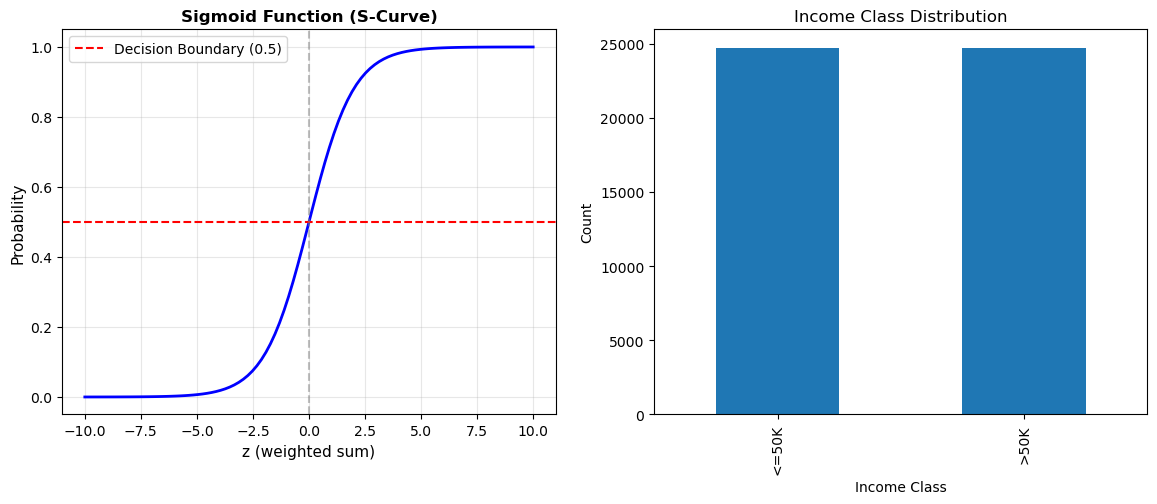

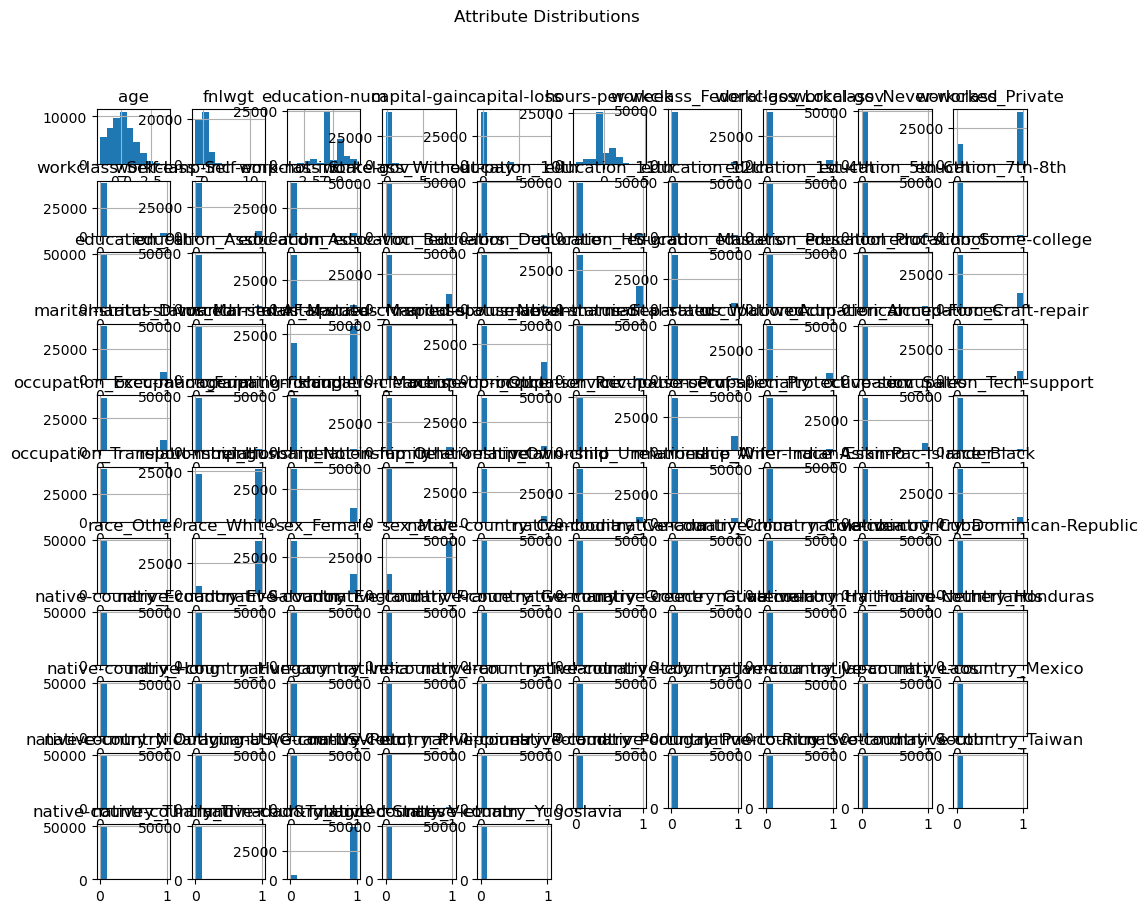

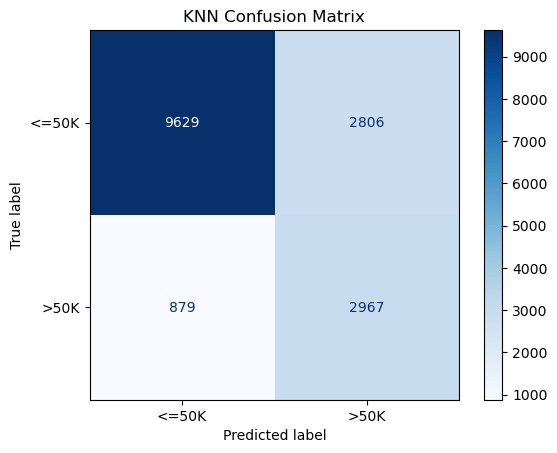

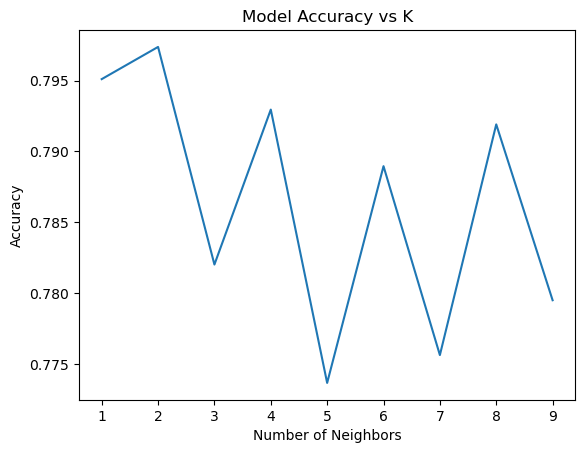


Weighted Ensemble (DT + Manual LR + KNN)
Ensemble: Using External Test Data.
Ensemble Training Set: 49440
Ensemble Test Set: 16281
Applying following: DT: 0.32, LR: 0.33, KNN: 0.35

Ensemble Model Accuracy: 0.8221
Confusion Matrix:
[[10623  1812]
 [ 1085  2761]]


In [9]:
if __name__ == "__main__":
    TRAIN_INPUT_FILE = 'census-income.data.csv'

    #Set this to 'census-income.test.csv' (or your filename) to use external testing
    #Set to None to use the original 80/20 split on the training file
    #TEST_INPUT_FILE = None
    TEST_INPUT_FILE = 'census-income.test.csv'

    FINAL_OUTPUT_FILE = 'final-train.csv'

    try:
        #Load & Preprocess TRAIN
        train_clean = knn_imputation(TRAIN_INPUT_FILE)
        train_balanced = oversampling(train_clean)

        #Load & Preprocess TEST
        test_processed = None
        if TEST_INPUT_FILE:
            print(f"\nProcessing External Test File: {TEST_INPUT_FILE}")
            test_clean = knn_imputation(TEST_INPUT_FILE)
            final_train_df, final_test_df = encoding_scaling(train_balanced, test_clean)
            test_processed = final_test_df
        else:
            final_train_df, _ = encoding_scaling(train_balanced, None)

        #Save Final Result - Training set
        final_train_df.to_csv(FINAL_OUTPUT_FILE, index=False)
        print(f"\nFinal training dataset saved to: {FINAL_OUTPUT_FILE}")
        print(f"\nTraining and Test (if provided) dataset have been curated. Oversampling not run on TEST: {FINAL_OUTPUT_FILE}")

        #Run Models
        #Pass the processed test df (if it exists) to all models
        decision_tree(final_train_df, test_processed)
        logistic_regression(final_train_df.copy(), test_processed)
        knn_classification(final_train_df.copy(), test_processed)
        weighted_ensemble(final_train_df.copy(), test_processed)

    except FileNotFoundError as e:
        print(f"Error: File not found. {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


# Summary and Conclusion

This project evaluated several machine learning models to predict whether an individual earns more than \$50,000 annually using the Census Income dataset. After preprocessing the data through missing value imputation, class balancing, normalization, and feature encoding, multiple classifiers were trained and evaluated, including Decision Tree, Logistic Regression, and K-Nearest Neighbors.

While each model demonstrated different strengths, the weighted ensemble approach produced the most balanced performance by combining the predictions of the individual models. This highlights the benefit of ensemble methods for improving overall prediction reliability.

This notebook focuses on the implementation and modeling workflow used in the analysis. A more detailed discussion of the methodology and results can be found in the accompanying project report.